In [1]:
from pydantic import BaseModel
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

c:\Users\jehoo\AppData\Local\anaconda3\envs\all_env\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class State(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]

In [3]:
def add(a: int, b: int) -> int:
    """
    Function to add two integers
    """
    return a+b

def subtract(a: int, b: int) -> int:
    """
    Function to subtract two integers
    """
    return a-b

def multiply(a: int, b: int) -> int:
    """
    Function to multiply two integers
    """
    return a*b

def divide(a: int, b: int) -> int:
    """
    Function to divide two integers
    """
    return a//b


In [4]:
import os
from dotenv import load_dotenv
from langchain_openai import AzureChatOpenAI

In [5]:
load_dotenv()

True

In [7]:
client = AzureChatOpenAI(
    api_key= os.getenv("AZURE_OPENAI_API_KEY"),
    azure_endpoint= os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_version= os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")
)

In [8]:
client.invoke("hello")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 7, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 0, 'engine_ttft_ms': 317, 'engine_ttlt_ms': 320, 'pre_inference_ms': 197, 'service_tbt_ms': 11, 'service_ttft_ms': 1011, 'service_ttlt_ms': 1218, 'user_visible_ttft_ms': 814}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-ELD6sfpesaJaWbXBHutbqUh31EbNh', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'fi

In [9]:
tools = [add, subtract, divide, multiply]
llm_with_tools = client.bind_tools(tools=tools, tool_choice="required")

In [10]:
def maths(state: State):
    return {"messages": llm_with_tools.invoke(state.messages)}

In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode

In [12]:
graph = StateGraph(State)

graph.add_node("function", maths)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "function")
graph.add_conditional_edges(
    "function",
    tools_condition
)

graph.add_edge("tools", "function")

graph_builder = graph.compile()

In [13]:
from IPython.display import display, Image
from pprint import pprint

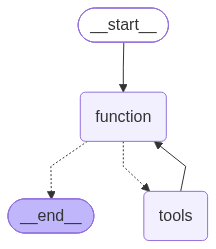

In [14]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))